# QE SCF Gamma-Inclusive Kindex Batch Analysis

Summarise every `source_db_id` in an AiiDA sweep group using set-based `QueryBuilder` projections. This notebook avoids per-node `load_node` calls and recursive `called_descendants` traversal.

The convergence labels reuse `goldilocks_data.analysis.convergence`: tail energy oscillation below 10/5/1 meV/atom for medium/well/ultra, with at least three remaining points.

The first run writes a reusable snapshot. Later runs load it by default; set `REFRESH_FROM_AIIDA = True` when new calculations have completed and a fresh snapshot is required.

## 1. Imports and profile

In [2]:
from __future__ import annotations

from datetime import datetime, timezone
import json
from pathlib import Path
import sys
from time import perf_counter

import pandas as pd
from IPython.display import display
from aiida import load_profile
from aiida.orm import Dict, Group, QueryBuilder, StructureData, WorkChainNode

repo_root = Path.cwd() if (Path.cwd() / 'pyproject.toml').exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root / 'src'))

from goldilocks_data.analysis import (
    ConvergenceThresholds,
    build_convergence_table,
    summarize_convergence,
)

profile = load_profile()
print(f'AiiDA profile loaded: {profile.name}')

AiiDA profile loaded: presto


## 2. Configuration

In [11]:
GROUP_LABEL = 'goldilocks/qe-scf/nospin/pseudodojo'
THRESHOLDS = ConvergenceThresholds(
    medium_mev_per_atom=5.0,
    well_mev_per_atom=3.0,
    ultra_mev_per_atom=1.0,
    min_tail_points=3,
)
REFRESH_FROM_AIIDA = True
WRITE_SNAPSHOT = True

OUTPUT_DIR = repo_root / 'campaigns/qe/kpoints/results'
RECORDS_PATH = OUTPUT_DIR / 'workchain-records.parquet'
SUMMARY_PATH = OUTPUT_DIR / 'source-summary.csv'
METADATA_PATH = OUTPUT_DIR / 'snapshot-metadata.json'
print(f'group: {GROUP_LABEL}')
print(f'output: {OUTPUT_DIR}')
print(f'refresh from AiiDA: {REFRESH_FROM_AIIDA}')

group: goldilocks/qe-scf/nospin/pseudodojo
output: campaigns/qe/kpoints/results
refresh from AiiDA: True


## 3. Bulk loaders

Each function executes one set-based database query and projects only the required scalar fields. Structure sites are fetched only for `kindex=0`, one row per source, rather than repeated for every WorkChain.

In [12]:
def load_workchain_metadata(group_label: str) -> pd.DataFrame:
    qb = QueryBuilder()
    qb.append(Group, filters={'label': group_label}, tag='group')
    qb.append(
        WorkChainNode,
        with_group='group',
        project=[
            'id',
            'extras.source_db_id',
            'extras.kindex',
            'extras.k_mesh',
            'attributes.process_state',
            'attributes.exit_status',
        ],
    )
    columns = ['pk', 'source_db_id', 'kindex', 'k_mesh', 'state', 'exit_status']
    return pd.DataFrame(qb.all(), columns=columns)


def load_output_energies(group_label: str) -> pd.DataFrame:
    qb = QueryBuilder()
    qb.append(Group, filters={'label': group_label}, tag='group')
    qb.append(WorkChainNode, with_group='group', tag='workchain', project='id')
    qb.append(
        Dict,
        with_incoming='workchain',
        edge_filters={'label': 'output_parameters'},
        project=['attributes.energy', 'attributes.energy_units'],
    )
    return pd.DataFrame(qb.all(), columns=['pk', 'energy', 'energy_units'])


def load_source_natoms(group_label: str) -> pd.DataFrame:
    qb = QueryBuilder()
    qb.append(Group, filters={'label': group_label}, tag='group')
    qb.append(
        WorkChainNode,
        with_group='group',
        filters={'extras.kindex': 0},
        tag='workchain',
        project='extras.source_db_id',
    )
    qb.append(
        StructureData,
        with_outgoing='workchain',
        edge_filters={'label': 'pw__structure'},
        project='attributes.sites',
    )
    rows = qb.all()
    return pd.DataFrame(
        [(source_db_id, len(sites)) for source_db_id, sites in rows],
        columns=['source_db_id', 'natoms'],
    )


## 4. Load a snapshot or refresh from AiiDA

A snapshot is used only when its AiiDA profile, group label, schema version, and convergence thresholds match the current configuration. Missing or incompatible files trigger an automatic refresh.

In [13]:
expected_snapshot_config = {
    'schema_version': 1,
    'aiida_profile': profile.name,
    'group_label': GROUP_LABEL,
    'thresholds': {
        'medium_mev_per_atom': THRESHOLDS.medium_mev_per_atom,
        'well_mev_per_atom': THRESHOLDS.well_mev_per_atom,
        'ultra_mev_per_atom': THRESHOLDS.ultra_mev_per_atom,
        'min_tail_points': THRESHOLDS.min_tail_points,
    },
}

snapshot_metadata = None
if METADATA_PATH.exists():
    snapshot_metadata = json.loads(METADATA_PATH.read_text())

snapshot_compatible = (
    snapshot_metadata is not None
    and all(snapshot_metadata.get(key) == value for key, value in expected_snapshot_config.items())
)
snapshot_available = RECORDS_PATH.exists() and SUMMARY_PATH.exists() and snapshot_compatible
use_snapshot = not REFRESH_FROM_AIIDA and snapshot_available

if use_snapshot:
    started = perf_counter()
    records_df = pd.read_parquet(RECORDS_PATH)
    summary_df = pd.read_csv(SUMMARY_PATH, dtype={'source_db_id': 'string'})
    records_df['source_db_id'] = records_df['source_db_id'].astype('string')
    data_origin = 'snapshot'
    print(f'loaded snapshot generated at {snapshot_metadata["generated_at"]}')
    print(f'loaded {len(records_df):,} records and {len(summary_df):,} summaries in {perf_counter() - started:.1f} s')
else:
    if not REFRESH_FROM_AIIDA and (RECORDS_PATH.exists() or SUMMARY_PATH.exists() or METADATA_PATH.exists()):
        print('snapshot is incomplete or incompatible; refreshing from AiiDA')

    started = perf_counter()
    metadata_df = load_workchain_metadata(GROUP_LABEL)
    metadata_seconds = perf_counter() - started

    started = perf_counter()
    energy_df = load_output_energies(GROUP_LABEL)
    energy_seconds = perf_counter() - started

    started = perf_counter()
    natoms_df = load_source_natoms(GROUP_LABEL)
    natoms_seconds = perf_counter() - started

    for frame in (metadata_df, natoms_df):
        frame['source_db_id'] = frame['source_db_id'].astype('string')

    records_df = metadata_df.merge(energy_df, on='pk', how='left', validate='one_to_one')
    records_df = records_df.merge(natoms_df, on='source_db_id', how='left', validate='many_to_one')
    records_df['energy_per_atom'] = records_df['energy'] / records_df['natoms']
    records_df = records_df.sort_values(['source_db_id', 'kindex']).reset_index(drop=True)
    summary_df = None
    data_origin = 'aiida'

    print(f'metadata: {len(metadata_df):,} rows in {metadata_seconds:.1f} s')
    print(f'energies: {len(energy_df):,} rows in {energy_seconds:.1f} s')
    print(f'structures: {len(natoms_df):,} rows in {natoms_seconds:.1f} s')

print(f'data origin: {data_origin}')
print(f'sources: {records_df["source_db_id"].nunique():,}')
display(records_df.head())

metadata: 127,921 rows in 6.9 s
energies: 127,530 rows in 9.2 s
structures: 16,208 rows in 6.3 s
data origin: aiida
sources: 16,208


,pk,source_db_id,kindex,k_mesh,state,exit_status,energy,energy_units,natoms,energy_per_atom
0,1753,100115,0,"[1, 1, 1]",finished,0.0,-15812.459053,eV,4,-3953.114763
1,1760,100115,1,"[2, 2, 1]",finished,0.0,-15826.530340,eV,4,-3956.632585
2,1770,100115,2,"[2, 2, 2]",finished,0.0,-15825.946106,eV,4,-3956.486526
3,1777,100115,3,"[3, 3, 2]",finished,0.0,-15826.990890,eV,4,-3956.747722
4,1787,100115,4,"[4, 4, 2]",finished,0.0,-15827.216717,eV,4,-3956.804179


## 5. Data-quality diagnostics

These checks make missing parsed outputs, missing structures, duplicate `(source_db_id, kindex)` pairs, and failed processes visible before convergence labels are assigned.

In [14]:
duplicate_mask = records_df.duplicated(['source_db_id', 'kindex'], keep=False)
diagnostics = pd.Series({
    'workchains': len(records_df),
    'sources': records_df['source_db_id'].nunique(),
    'finished': int(records_df['state'].eq('finished').sum()),
    'finished_ok': int((records_df['state'].eq('finished') & records_df['exit_status'].eq(0)).sum()),
    'with_energy': int(records_df['energy'].notna().sum()),
    'finished_without_energy': int((records_df['state'].eq('finished') & records_df['energy'].isna()).sum()),
    'without_natoms': int(records_df['natoms'].isna().sum()),
    'duplicate_source_kindex_rows': int(duplicate_mask.sum()),
})
display(diagnostics.rename('count').to_frame())

if duplicate_mask.any():
    display(records_df.loc[duplicate_mask].sort_values(['source_db_id', 'kindex', 'pk']).head(50))

,count
workchains,127921
sources,16208
finished,127919
finished_ok,127530
with_energy,127530
finished_without_energy,389
without_natoms,0
duplicate_source_kindex_rows,0


## 6. Batch convergence summary

The loop is over in-memory DataFrame groups. It performs no AiiDA ORM or database calls.

In [15]:
def convergence_summary_record(source_db_id: str, source_df: pd.DataFrame) -> dict:
    convergence_df = build_convergence_table(source_df, THRESHOLDS)
    return {'source_db_id': source_db_id, **summarize_convergence(convergence_df, THRESHOLDS)}


if summary_df is None:
    started = perf_counter()
    submission_df = (
        records_df.assign(
        finished=records_df['state'].eq('finished'),
        finished_ok=records_df['state'].eq('finished') & records_df['exit_status'].eq(0),
        has_energy=records_df['energy'].notna(),
        )
        .groupby('source_db_id', sort=True, observed=True)
        .agg(
        n_workchains=('pk', 'size'),
        n_finished=('finished', 'sum'),
        n_finished_ok=('finished_ok', 'sum'),
        n_finished_with_energy=('has_energy', 'sum'),
        max_submitted_kindex=('kindex', 'max'),
        )
        .reset_index()
    )

    convergence_rows = [
        convergence_summary_record(str(source_db_id), source_df)
        for source_db_id, source_df in records_df.groupby('source_db_id', sort=True, observed=True)
    ]
    convergence_summary_df = pd.DataFrame(convergence_rows)
    summary_df = submission_df.merge(
        convergence_summary_df,
        on='source_db_id',
        how='left',
        validate='one_to_one',
    )
    summary_df = summary_df.sort_values(
        ['ultra_converged', 'source_db_id'],
        ascending=[False, True],
    ).reset_index(drop=True)
    summary_seconds = perf_counter() - started
    print(f'summarised {len(summary_df):,} sources in {summary_seconds:.1f} s')
else:
    print(f'using {len(summary_df):,} cached source summaries')

print(f'ultra converged: {int(summary_df["ultra_converged"].sum()):,}')
display(summary_df.head(20))

summarised 16,208 sources in 40.5 s
ultra converged: 15,474


,source_db_id,n_workchains,n_finished,n_finished_ok,n_finished_with_energy,max_submitted_kindex,medium_kindex,well_kindex,ultra_kindex,ultra_converged,max_finished_kindex,ultra_k_mesh,ultra_energy_per_atom,ultra_oscillation_meV_per_atom,ultra_pk
0,100115,23,23,23,23,22,11.0,14.0,19.0,True,22.0,"[13, 13, 8]",-3956.806408,0.633608,1916.0
1,1001468,6,6,6,6,5,3.0,3.0,3.0,True,5.0,"[2, 2, 2]",-710.458276,0.563964,1984.0
2,100172,6,6,6,6,5,1.0,1.0,3.0,True,5.0,"[2, 2, 2]",-1136.876691,0.484678,2042.0
3,100492,5,5,5,5,4,1.0,2.0,2.0,True,4.0,"[2, 2, 2]",-817.736591,0.461744,2087.0
4,100560,14,14,14,14,13,10.0,10.0,11.0,True,13.0,"[8, 8, 5]",-2596.423066,0.692302,2210.0
5,100738,5,5,5,5,4,2.0,2.0,2.0,True,4.0,"[2, 2, 2]",-560.309468,0.918871,2255.0
6,1008090,4,4,4,4,3,1.0,1.0,1.0,True,3.0,"[2, 1, 1]",-331.545360,0.043342,2293.0
7,1008164,6,6,6,6,5,2.0,2.0,3.0,True,5.0,"[2, 2, 2]",-1026.488522,0.343669,2348.0
8,100839,6,6,6,6,5,2.0,2.0,3.0,True,5.0,"[4, 4, 4]",-1960.427029,0.276409,2403.0
9,10098,12,12,12,12,11,4.0,5.0,9.0,True,11.0,"[2, 7, 3]",-810.321121,0.942051,2509.0


## 7. Aggregate statistics

In [16]:
level_counts = pd.Series({
    'sources': len(summary_df),
    'medium_converged': int(summary_df['medium_kindex'].notna().sum()),
    'well_converged': int(summary_df['well_kindex'].notna().sum()),
    'ultra_converged': int(summary_df['ultra_converged'].sum()),
    'not_ultra_converged': int((~summary_df['ultra_converged']).sum()),
})
display(level_counts.rename('count').to_frame())

display(
    summary_df.loc[summary_df['ultra_converged'], 'ultra_kindex']
    .value_counts()
    .sort_index()
    .rename_axis('ultra_kindex')
    .reset_index(name='source_count')
)

,count
sources,16208
medium_converged,16023
well_converged,15974
ultra_converged,15474
not_ultra_converged,734


,ultra_kindex,source_count
0,0.0,221
1,1.0,1978
2,2.0,3254
3,3.0,2888
4,4.0,1728
5,5.0,1314
6,6.0,764
7,7.0,586
8,8.0,566
9,9.0,444


## 8. Inspect one source from the in-memory batch

In [17]:
SOURCE_DB_ID_VIEW = '161380'
source_df = records_df[records_df['source_db_id'].eq(SOURCE_DB_ID_VIEW)].copy()
source_convergence_df = build_convergence_table(source_df, THRESHOLDS)
display(summary_df[summary_df['source_db_id'].eq(SOURCE_DB_ID_VIEW)])
display(source_convergence_df)

,source_db_id,n_workchains,n_finished,n_finished_ok,n_finished_with_energy,max_submitted_kindex,medium_kindex,well_kindex,ultra_kindex,ultra_converged,max_finished_kindex,ultra_k_mesh,ultra_energy_per_atom,ultra_oscillation_meV_per_atom,ultra_pk
297,161380,19,19,19,19,18,6.0,8.0,16.0,True,18.0,"[14, 14, 4]",-816.254506,0.574502,1934390.0


,pk,source_db_id,kindex,k_mesh,state,exit_status,energy,energy_units,natoms,energy_per_atom,energy_oscillation_meV_per_cell,energy_oscillation_meV_per_atom,label
0,32417,161380,0,"[1, 1, 1]",finished,0.0,-3268.722550,eV,4,-817.180637,4889.707962,1222.426990,unconverged
1,32428,161380,1,"[2, 2, 1]",finished,0.0,-3263.832842,eV,4,-815.958211,1274.968081,318.742020,unconverged
2,32449,161380,2,"[3, 3, 1]",finished,0.0,-3265.107810,eV,4,-816.276953,197.527621,49.381905,unconverged
3,32460,161380,3,"[4, 4, 1]",finished,0.0,-3264.953403,eV,4,-816.238351,177.515581,44.378895,unconverged
4,32472,161380,4,"[4, 4, 2]",finished,0.0,-3264.910282,eV,4,-816.227571,177.515581,44.378895,unconverged
5,32486,161380,5,"[5, 5, 2]",finished,0.0,-3265.087798,eV,4,-816.271950,76.303777,19.075944,unconverged
6,32504,161380,6,"[6, 6, 2]",finished,0.0,-3265.016129,eV,4,-816.254032,15.308073,3.827018,medium
7,32518,161380,7,"[7, 7, 2]",finished,0.0,-3265.026802,eV,4,-816.256701,15.308073,3.827018,medium-to-well
8,32533,161380,8,"[8, 8, 2]",finished,0.0,-3265.015174,eV,4,-816.253794,7.754891,1.938723,well
9,32549,161380,9,"[8, 8, 3]",finished,0.0,-3265.011494,eV,4,-816.252874,7.754891,1.938723,well-to-ultra


## 9. SSSP vs PseudoDojo ultra-mesh comparison

Only structures with different SSSP and PseudoDojo ultra meshes are shown. The comparison uses the actual `(k1, k2, k3)` meshes rather than the numerical k-index because the two campaigns used different mesh schedules.

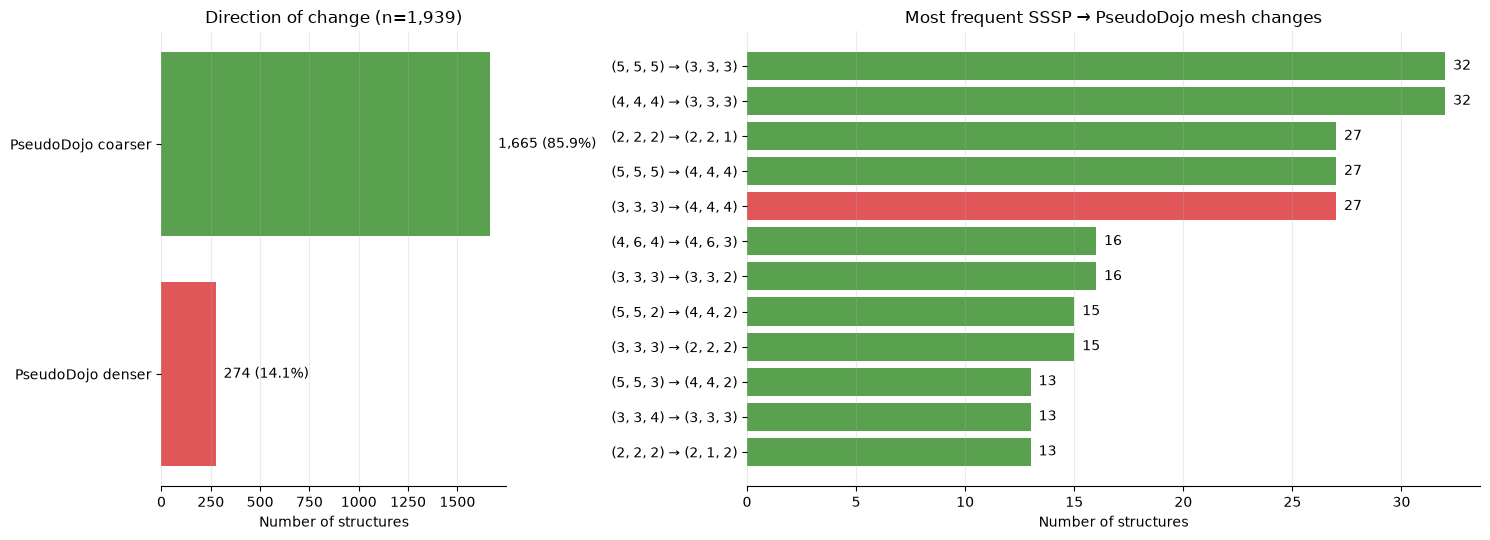

,count,mean,std,min,10%,25%,50%,75%,90%,max
direction,,,,,,,,,,
PseudoDojo coarser,1665.0,0.607099,0.189806,0.015625,0.355556,0.500000,0.642857,0.75000,0.833333,0.944444
PseudoDojo denser,274.0,2.026034,1.332380,1.055556,1.180554,1.333333,1.687500,2.37037,2.974636,15.625000


In [3]:
import ast
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

plot_repo_root = Path.cwd() if (Path.cwd() / 'pyproject.toml').exists() else Path.cwd().parent
pseudo_summary = pd.read_csv(
    plot_repo_root / 'campaigns/qe/kpoints/results/source-summary.csv',
    dtype={'source_db_id': 'string'},
)
SSSP_DATA_DIR = Path(os.environ['GOLDILOCKS_SSSP_DATA_DIR'])
sssp_summary = pd.read_csv(SSSP_DATA_DIR / 'convergence_summary.csv', dtype={'source_db_id': 'string'})
sssp_full = pd.read_csv(
    SSSP_DATA_DIR / 'full_scf_summary/scf_calc_summary.csv',
    dtype={'source_db_id': 'string'},
)
sssp_ultra = pd.concat([
    sssp_summary[sssp_summary['Convergence Notes'].eq('ultra')],
    sssp_full[sssp_full['Convergence Notes (modified)'].eq('ultra')],
], ignore_index=True)
sssp_ultra = (
    sssp_ultra.sort_values('k_index')
    .drop_duplicates('source_db_id', keep='last')
    [['source_db_id', 'k1', 'k2', 'k3']]
)

pseudo_ultra = pseudo_summary.loc[
    pseudo_summary['ultra_converged'], ['source_db_id', 'ultra_k_mesh']
].copy()
pseudo_ultra['pseudo_mesh'] = pseudo_ultra['ultra_k_mesh'].map(
    lambda value: tuple(ast.literal_eval(value)) if isinstance(value, str) else tuple(value)
)
comparison = pseudo_ultra.merge(sssp_ultra, on='source_db_id', validate='one_to_one')
comparison['sssp_mesh'] = list(zip(comparison['k1'], comparison['k2'], comparison['k3']))
comparison['pseudo_points'] = comparison['pseudo_mesh'].map(np.prod)
comparison['sssp_points'] = comparison['sssp_mesh'].map(np.prod)
comparison['mesh_ratio'] = comparison['pseudo_points'] / comparison['sssp_points']

mesh_changes = comparison[comparison['pseudo_mesh'].ne(comparison['sssp_mesh'])].copy()
mesh_changes['direction'] = np.select(
    [
        mesh_changes['pseudo_points'].lt(mesh_changes['sssp_points']),
        mesh_changes['pseudo_points'].gt(mesh_changes['sssp_points']),
    ],
    ['PseudoDojo coarser', 'PseudoDojo denser'],
    default='Different shape, same size',
)
mesh_changes['transition'] = (
    mesh_changes['sssp_mesh'].astype(str) + ' → ' + mesh_changes['pseudo_mesh'].astype(str)
)

direction_order = ['PseudoDojo coarser', 'PseudoDojo denser', 'Different shape, same size']
direction_counts = mesh_changes['direction'].value_counts().reindex(direction_order).dropna().astype(int)
direction_percent = 100 * direction_counts / len(mesh_changes)
top_transitions = mesh_changes['transition'].value_counts().head(12).sort_values()
transition_direction = mesh_changes.drop_duplicates('transition').set_index('transition')['direction']
color_map = {
    'PseudoDojo coarser': '#59A14F',
    'PseudoDojo denser': '#E15759',
    'Different shape, same size': '#4C78A8',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={'width_ratios': [0.8, 1.7]})
bars = axes[0].barh(
    direction_counts.index,
    direction_counts.values,
    color=[color_map[label] for label in direction_counts.index],
)
axes[0].invert_yaxis()
axes[0].set_xlabel('Number of structures')
axes[0].set_title(f'Direction of change (n={len(mesh_changes):,})')
axes[0].grid(axis='x', alpha=0.25)
for bar, count, percent in zip(bars, direction_counts, direction_percent, strict=True):
    axes[0].text(count, bar.get_y() + bar.get_height() / 2, f'  {count:,} ({percent:.1f}%)', va='center')

transition_colors = [color_map[transition_direction[label]] for label in top_transitions.index]
bars = axes[1].barh(top_transitions.index, top_transitions.values, color=transition_colors)
axes[1].set_xlabel('Number of structures')
axes[1].set_title('Most frequent SSSP → PseudoDojo mesh changes')
axes[1].grid(axis='x', alpha=0.25)
for bar, count in zip(bars, top_transitions.values, strict=True):
    axes[1].text(count, bar.get_y() + bar.get_height() / 2, f'  {count}', va='center')

for ax in axes:
    ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()
plt.show()

display(
    mesh_changes.groupby('direction')['mesh_ratio']
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
)

## 10. Export

When data came from AiiDA, `WRITE_SNAPSHOT = True` writes the complete per-WorkChain records, per-source summary, and a metadata file describing the profile, group, thresholds, generation time, and row counts. Fixed filenames intentionally replace the previous snapshot.

In [18]:
if WRITE_SNAPSHOT and data_origin == 'aiida':
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    records_df.to_parquet(RECORDS_PATH, index=False)
    summary_df.to_csv(SUMMARY_PATH, index=False)
    snapshot_metadata = {
        **expected_snapshot_config,
        'generated_at': datetime.now(timezone.utc).isoformat(),
        'workchain_count': len(records_df),
        'source_count': len(summary_df),
        'ultra_converged_count': int(summary_df['ultra_converged'].sum()),
    }
    METADATA_PATH.write_text(json.dumps(snapshot_metadata, indent=2) + '\n')
    print(f'wrote {RECORDS_PATH}')
    print(f'wrote {SUMMARY_PATH}')
    print(f'wrote {METADATA_PATH}')
elif data_origin == 'snapshot':
    print('snapshot already loaded; no files rewritten.')
else:
    print('WRITE_SNAPSHOT is False; no files written.')

wrote campaigns/qe/kpoints/results/workchain-records.parquet
wrote campaigns/qe/kpoints/results/source-summary.csv
wrote campaigns/qe/kpoints/results/snapshot-metadata.json
